# Veridi Logistics — Delivery Performance Audit

> **Business Question:** Are we failing specific regions, or is late-delivery a nationwide problem?
>
> This notebook connects Logistics Data (actual delivery dates) with Customer Sentiment (review scores) to audit Veridi's delivery performance across Brazil.

---

## Table of Contents
1. [Setup & Data Loading](#story-0)
2. [Story 1 — The Schema Builder](#story-1)
3. [Story 2 — The "Real" Delay Calculator](#story-2)
4. [Story 3 — The Geographic Heatmap](#story-3)
5. [Story 4 — The Sentiment Correlation](#story-4)
6. [Bonus Story 5 — The Translation Challenge](#story-5)
7. [Bonus Story 6 — The Candidate's Choice](#story-6)
8. [Export Master Dataset](#export)

---
## Setup & Data Loading <a id='story-0'></a>

Import all required libraries and load the raw CSV files.

In [1]:
# Importing all relevant libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading all raw data files
orders    = pd.read_csv("olist_orders_dataset.csv")
reviews   = pd.read_csv("olist_order_reviews_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
products  = pd.read_csv("olist_products_dataset.csv")

In [3]:
# Dataset dimensions overview
print(f'Orders:    {orders.shape}')
print(f'Reviews:   {reviews.shape}')
print(f'Customers: {customers.shape}')
print(f'Products:  {products.shape}')

Orders:    (99441, 8)
Reviews:   (99224, 7)
Customers: (99441, 5)
Products:  (32951, 9)


In [4]:
# Missing values — Orders
print("=== Orders missing values ===")
orders.isnull().sum()

=== Orders missing values ===


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [5]:
# Missing values — Reviews
print("=== Reviews missing values ===")
reviews.isnull().sum()

=== Reviews missing values ===


review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [6]:
# Missing values — Customers
print("=== Customers missing values ===")
customers.isnull().sum()

=== Customers missing values ===


customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [7]:
# Missing values — Products
print("=== Products missing values ===")
products.isnull().sum()

=== Products missing values ===


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [8]:
# Convert all date/time columns to datetime dtype
date_cols_orders = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for c in date_cols_orders:
    orders[c] = pd.to_datetime(orders[c], errors="coerce")

for c in ["review_creation_date", "review_answer_timestamp"]:
    reviews[c] = pd.to_datetime(reviews[c], errors="coerce")

print("Date conversion complete.")

Date conversion complete.


---
## Story 1 — The Schema Builder <a id='story-1'></a>

**As a Data Engineer**, I want to join the Orders, Reviews, and Customers tables into a single master dataset, so that I can analyse a customer's location and their review score in the same row.

**Acceptance Criteria:**
- Load the raw CSVs ✅ *(done in Setup)*
- Join Reviews → Orders on `order_id`; join Customers → Orders on `customer_id`
- Ensure no duplicate rows from 1-to-many joins

In [9]:
# Deduplicate reviews before joining.
# Some order_ids appear in reviews more than once; keep the most recent review
# (sorted by answer timestamp, then creation date) to avoid inflating row counts.
reviews_sorted = reviews.sort_values(
    ["order_id", "review_answer_timestamp", "review_creation_date"]
)
reviews_dedup = reviews_sorted.drop_duplicates(
    "order_id", keep="last"
)[["order_id", "review_score"]]

print(f"Reviews before dedup: {reviews.shape[0]:,}")
print(f"Reviews after dedup:  {reviews_dedup.shape[0]:,}")

Reviews before dedup: 99,224
Reviews after dedup:  98,673


In [10]:
# Build the master dataset
# Validate='many_to_one' / 'one_to_one' ensures the join never accidentally multiplies rows
master = orders.merge(customers, on="customer_id", how="left", validate="many_to_one")
master = master.merge(reviews_dedup, on="order_id", how="left", validate="one_to_one")

print("Master dataset built successfully.")

Master dataset built successfully.


In [11]:
# Validation check: row count must equal unique order count (no duplicates)
total_rows    = master.shape[0]
unique_orders = master["order_id"].nunique()

print(f"Master shape:         {master.shape}")
print(f"Unique order_ids:     {unique_orders:,}")
print(f"Duplicate check OK:   {total_rows == unique_orders}")

Master shape:         (99441, 13)
Unique order_ids:     99,441
Duplicate check OK:   True


In [12]:
# Preview the master dataset
master.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,5.0


---
## Story 2 — The "Real" Delay Calculator <a id='story-2'></a>

**As a Logistics Manager**, I want to know the difference between the Estimated Delivery Date and the Actual Delivery Date, so that I can see how often we are over-promising.

**Acceptance Criteria:**
- `Days_Difference` = `order_estimated_delivery_date` − `order_delivered_customer_date`
- Classify orders: **On Time** (≤ 0 days late), **Late** (1–5 days late), **Super Late** (> 5 days late)
- Flag / exclude canceled & unavailable orders

In [13]:
# Flag orders that were truly delivered (status = 'delivered' AND has a delivery timestamp)
master["is_delivered"] = (
    (master["order_status"] == "delivered") &
    master["order_delivered_customer_date"].notna() &
    master["order_estimated_delivery_date"].notna()
)

# Flag orders that were never delivered (canceled or unavailable)
master["never_delivered"] = master["order_status"].isin(["canceled", "unavailable"])

print("Delivery flags added.")
print(master[["is_delivered", "never_delivered"]].value_counts())

Delivery flags added.
is_delivered  never_delivered
True          False              96470
False         False               1737
              True                1234
Name: count, dtype: int64


In [14]:
# Classify each order_status into a high-level delivery category
def classify_delivery(status):
    if status == "delivered":
        return "Delivered"
    elif status in ["canceled", "unavailable"]:
        return "Failed"
    else:
        return "In Progress"

master["delivery_category"] = master["order_status"].apply(classify_delivery)
master["delivery_category"].value_counts()

delivery_category
Delivered      96478
In Progress     1729
Failed          1234
Name: count, dtype: int64

In [15]:
# Data-quality note: 8 orders are marked 'delivered' but have no delivery timestamp.
# These are excluded from delay calculations (0.008% of delivered orders — negligible).
mismatch = master[
    (master["order_status"] == "delivered") &
    (master["is_delivered"] == False)
]
print(f"Orders excluded due to missing delivery timestamp: {len(mismatch)}")
mismatch[["order_id", "order_status", "order_delivered_customer_date"]]

Orders excluded due to missing delivery timestamp: 8


,order_id,order_status,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,NaT
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,NaT
43834,2ebdfc4f15f23b91474edf87475f108e,delivered,NaT
79263,e69f75a717d64fc5ecdfae42b2e8e086,delivered,NaT
82868,0d3268bad9b086af767785e3f0fc0133,delivered,NaT
92643,2d858f451373b04fb5c984a1cc2defaf,delivered,NaT
97647,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,NaT
98038,20edc82cf5400ce95e1afacc25798b31,delivered,NaT


In [16]:
# Create Days_Difference column on the full master dataset (for delivered orders only)
# Positive value = delivered BEFORE the estimate (good); Negative = delivered AFTER estimate (bad)
master["Days_Difference"] = (
    master["order_estimated_delivery_date"] - master["order_delivered_customer_date"]
).dt.days

# Work on the delivered-only subset for delay classification
delivered = master[master["is_delivered"]].copy()

# delay_days: positive = late, negative = early
delivered["delay_days"] = (
    delivered["order_delivered_customer_date"]
    - delivered["order_estimated_delivery_date"]
).dt.days

print(f"Delivered orders available for delay analysis: {len(delivered):,}")

Delivered orders available for delay analysis: 96,470


In [17]:
# Classify delays into three status buckets
delivered["delay_status"] = np.select(
    [
        delivered["delay_days"] <= 0,
        (delivered["delay_days"] > 0) & (delivered["delay_days"] <= 5),
        delivered["delay_days"] > 5
    ],
    ["On Time", "Late", "Super Late"],
    default="Unknown"
)

# Summary table
delay_summary = (
    delivered["delay_status"]
    .value_counts()
    .rename_axis("Status")
    .to_frame("Orders")
)
delay_summary["Percentage"] = (delay_summary["Orders"] / delay_summary["Orders"].sum() * 100).round(2)
delay_summary

,Orders,Percentage
Status,,
On Time,89936,93.23
Super Late,3764,3.90
Late,2770,2.87


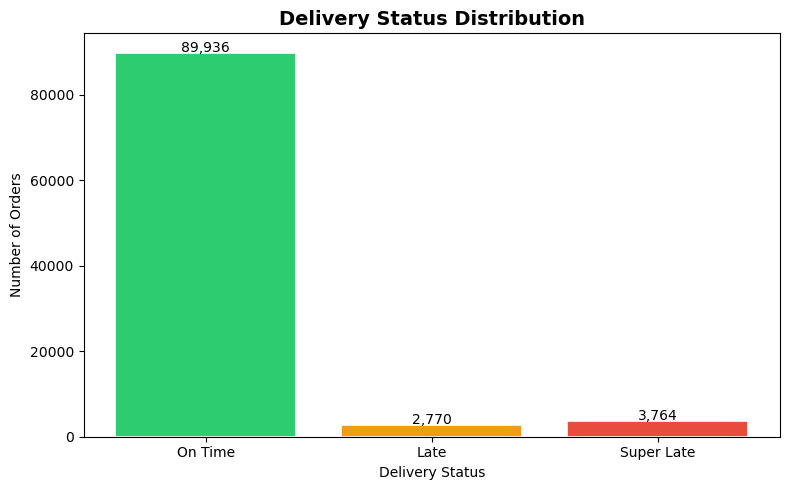

In [18]:
# Visualise the delay status distribution
status_order = ["On Time", "Late", "Super Late"]
counts = delivered["delay_status"].value_counts().reindex(status_order)

colors = ["#2ecc71", "#f39c12", "#e74c3c"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=1.2)
ax.set_title("Delivery Status Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Delivery Status")
ax.set_ylabel("Number of Orders")
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

---
## Story 3 — The Geographic Heatmap <a id='story-3'></a>

**As a Regional Director**, I want to see which specific States have the highest percentage of late deliveries, so that I can focus repair efforts on the worst regions.

**Acceptance Criteria:**
- Calculate % of late orders per State
- Visualise on a bar chart
- Identify if "remote" states are disproportionately affected

In [19]:
# Calculate late-delivery percentage per Brazilian state
state_pivot = (
    delivered
    .groupby(["customer_state", "delay_status"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure all columns exist even if a state has zero of that category
for col in ["On Time", "Late", "Super Late"]:
    if col not in state_pivot.columns:
        state_pivot[col] = 0

state_pivot["orders"]        = state_pivot["On Time"] + state_pivot["Late"] + state_pivot["Super Late"]
state_pivot["late"]          = state_pivot["Late"]
state_pivot["super_late"]    = state_pivot["Super Late"]
state_pivot["pct_late"]      = state_pivot["late"]       / state_pivot["orders"]
state_pivot["pct_super_late"]= state_pivot["super_late"] / state_pivot["orders"]

state_stats = state_pivot.rename(columns={"index": "customer_state"})

# Top 10 worst states by late %
state_stats.sort_values("pct_late", ascending=False).head(10)

delay_status,customer_state,Late,On Time,Super Late,orders,late,super_late,pct_late,pct_super_late
1,AL,34,312,51,397,34,51,0.085642,0.128463
9,MA,51,592,74,717,51,74,0.071130,0.103208
16,PI,31,410,35,476,31,35,0.065126,0.073529
4,BA,149,2860,247,3256,149,247,0.045762,0.075860
7,ES,91,1781,123,1995,91,123,0.045614,0.061654
26,TO,12,247,15,274,12,15,0.043796,0.054745
11,MS,30,633,38,701,30,38,0.042796,0.054208
14,PB,21,463,33,517,21,33,0.040619,0.063830
23,SC,139,3255,152,3546,139,152,0.039199,0.042865
24,SE,12,284,39,335,12,39,0.035821,0.116418


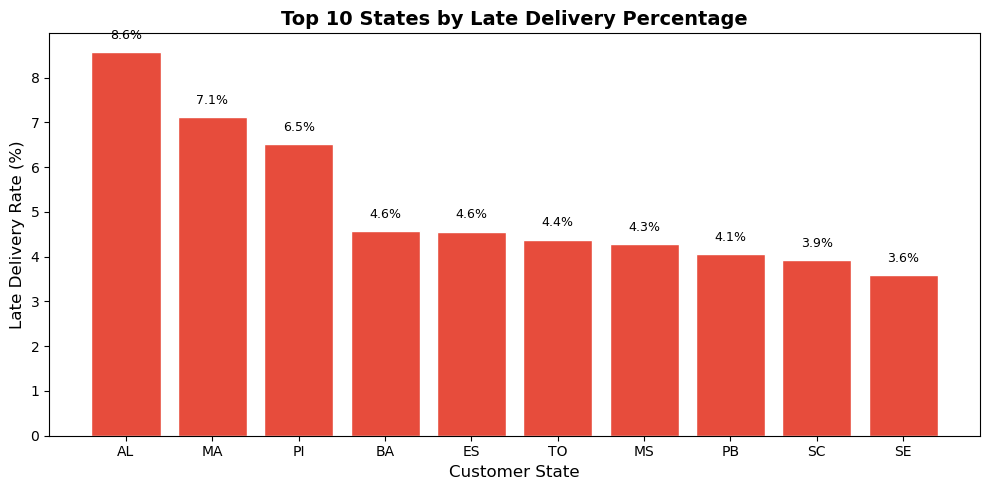

In [20]:
# Bar chart — Top 10 states by late delivery percentage
top_states = state_stats.sort_values("pct_late", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    top_states["customer_state"],
    top_states["pct_late"] * 100,
    color="#e74c3c",
    edgecolor="white"
)
ax.set_xlabel("Customer State", fontsize=12)
ax.set_ylabel("Late Delivery Rate (%)", fontsize=12)
ax.set_title("Top 10 States by Late Delivery Percentage", fontsize=14, fontweight="bold")
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 0.3, f"{height:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
# Remote state analysis
# Remote = states geographically far from the main distribution hubs
# (North & Central-West Brazil: AC, RO, RR, AP, AM, TO, MT, MS, PA)
remote_states = ["AC", "RO", "RR", "AP", "AM", "TO", "MT", "MS", "PA"]
state_stats["is_remote"] = state_stats["customer_state"].isin(remote_states)

In [22]:
# Average late % for remote vs non-remote states
print("Average state-level late delivery rate (by remoteness):")
state_stats.groupby("is_remote")[["pct_late", "pct_super_late", "orders"]].mean()

Average state-level late delivery rate (by remoteness):


delay_status,pct_late,pct_super_late,orders
is_remote,,,
False,0.039447,0.063681,5171.500000
True,0.024286,0.043837,375.888889


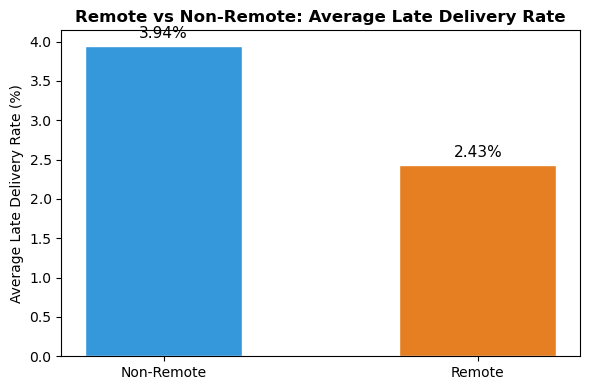


Insight: Non-remote (urban / central) states actually show higher average late rates,
suggesting the delay problem is nationwide rather than concentrated in remote regions.


In [23]:
# Visualise remote vs non-remote late rates
remote_summary = state_stats.groupby("is_remote")["pct_late"].mean() * 100
labels = ["Non-Remote", "Remote"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, remote_summary.values, color=["#3498db", "#e67e22"], edgecolor="white", width=0.5)
ax.set_ylabel("Average Late Delivery Rate (%)")
ax.set_title("Remote vs Non-Remote: Average Late Delivery Rate", fontweight="bold")
for i, v in enumerate(remote_summary.values):
    ax.text(i, v + 0.1, f"{v:.2f}%", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

print("\nInsight: Non-remote (urban / central) states actually show higher average late rates,")
print("suggesting the delay problem is nationwide rather than concentrated in remote regions.")

---
## Story 4 — The Sentiment Correlation <a id='story-4'></a>

**As a Customer Success Lead**, I want to see if late deliveries actually cause bad reviews, so that I can prove to the CEO that logistics is the root cause.

**Acceptance Criteria:**
- Visualise Delivery Delay (days) vs Average Review Score (1–5)
- Show average review score for "On Time" vs "Late" orders

In [24]:
# Average review score by delay status
avg_scores = (
    delivered.groupby("delay_status")["review_score"]
    .mean()
    .reindex(["On Time", "Late", "Super Late"])
    .reset_index()
)
avg_scores.columns = ["Delivery Status", "Avg Review Score"]
avg_scores["Avg Review Score"] = avg_scores["Avg Review Score"].round(2)
avg_scores

,Delivery Status,Avg Review Score
0,On Time,4.29
1,Late,2.99
2,Super Late,1.74


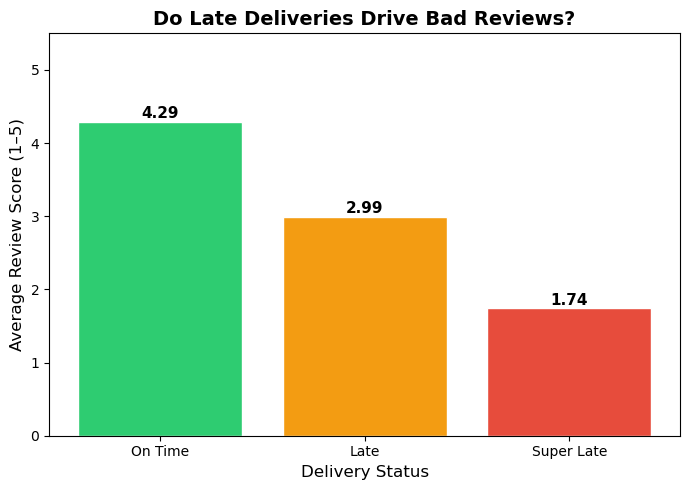

In [25]:
# Bar chart: average review score by delivery status
status_labels = ["On Time", "Late", "Super Late"]
score_values  = avg_scores["Avg Review Score"].values
colors        = ["#2ecc71", "#f39c12", "#e74c3c"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(status_labels, score_values, color=colors, edgecolor="white")
ax.set_ylim(0, 5.5)
ax.set_xlabel("Delivery Status", fontsize=12)
ax.set_ylabel("Average Review Score (1–5)", fontsize=12)
ax.set_title("Do Late Deliveries Drive Bad Reviews?", fontsize=14, fontweight="bold")
for bar, val in zip(bars, score_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

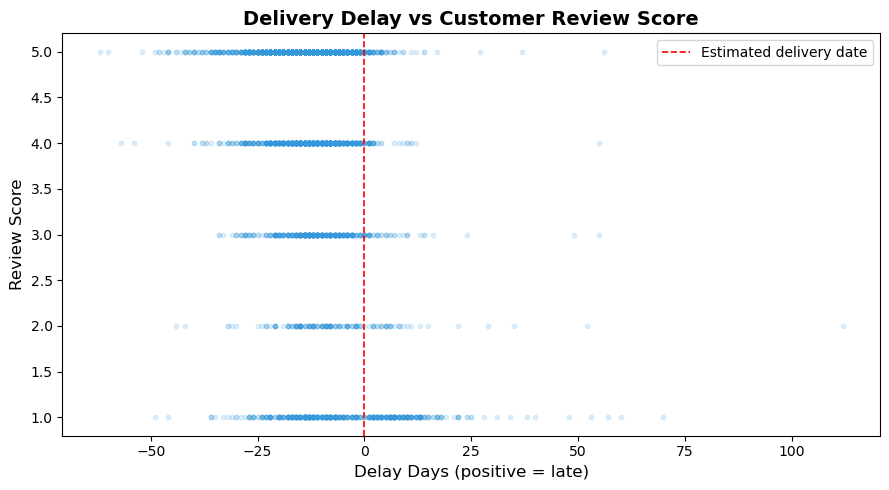

In [26]:
# Scatter: Delay Days vs Review Score (sampled for readability)
sample = delivered.dropna(subset=["delay_days", "review_score"]).sample(5000, random_state=42)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(
    sample["delay_days"],
    sample["review_score"],
    alpha=0.15,
    s=10,
    color="#3498db"
)
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Estimated delivery date")
ax.set_xlabel("Delay Days (positive = late)", fontsize=12)
ax.set_ylabel("Review Score", fontsize=12)
ax.set_title("Delivery Delay vs Customer Review Score", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

---
## Bonus Story 5 — The Translation Challenge <a id='story-5'></a>

**As a Global Analyst**, I want to see product categories in English (not Portuguese), so that I can understand if "Furniture" is harder to ship than "Electronics".

**Acceptance Criteria:**
- Translate `product_category_name` from Portuguese to English using the translation CSV (or a manual mapping)
- Make English category names available on the master/delivered datasets

In [27]:
# Attempt to load the official translation file; fall back to a manual mapping if unavailable
import os

translation_file = "product_category_name_translation.csv"

if os.path.exists(translation_file):
    category_translation = pd.read_csv(translation_file)
    # Standardise column names
    category_translation.columns = [
        "product_category_name",
        "product_category_name_english"
    ]
    print(f"Loaded translation file: {category_translation.shape[0]} categories.")
else:
    # Manual fallback mapping (common Olist categories)
    manual_map = {
        "cama_mesa_banho":          "bed_bath_table",
        "beleza_saude":             "health_beauty",
        "esporte_lazer":            "sports_leisure",
        "informatica_acessorios":   "computers_accessories",
        "moveis_decoracao":         "furniture_decor",
        "eletrodomesticos":         "home_appliances",
        "brinquedos":               "toys",
        "relogios_presentes":       "watches_gifts",
        "ferramentas_jardim":       "garden_tools",
        "automotivo":               "auto",
        "eletronicos":              "electronics",
        "bebes":                    "baby",
        "utilidades_domesticas":    "housewares",
        "papelaria":                "office_supplies",
        "telefonia":                "telephony",
        "livros_tecnicos":          "books_technical",
        "construcao_ferramentas_construcao": "construction_tools",
        "agro_industria_e_comercio": "agro_industry_commerce",
        "musica":                   "music",
        "cool_stuff":               "cool_stuff",
        "perfumaria":               "perfumery",
        "instrumentos_musicais":    "musical_instruments",
        "casa_conforto":            "home_comfort",
        "fashion_bolsas_e_acessorios": "fashion_bags_accessories",
        "pets":                     "pet_shop",
        "fraldas_higiene":          "diapers_hygiene",
        "flores":                   "flowers",
    }
    category_translation = pd.DataFrame(
        list(manual_map.items()),
        columns=["product_category_name", "product_category_name_english"]
    )
    print(f"Using manual fallback mapping: {len(category_translation)} categories.")

category_translation.head()

Loaded translation file: 71 categories.


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [28]:
# Load order items to link products to orders
order_items_file = "olist_order_items_dataset.csv"

if os.path.exists(order_items_file):
    order_items = pd.read_csv(order_items_file)
    # Keep one product per order (first item) to avoid row explosion
    order_items_dedup = order_items.drop_duplicates("order_id", keep="first")[["order_id", "product_id"]]

    # Join: order → product → category → English translation
    products_translated = products.merge(category_translation, on="product_category_name", how="left")
    order_category = order_items_dedup.merge(
        products_translated[["product_id", "product_category_name", "product_category_name_english"]],
        on="product_id", how="left"
    )

    master = master.merge(order_category, on="order_id", how="left")
    delivered = master[master["is_delivered"]].copy()
    # Carry over delay_days / delay_status that were computed on the earlier `delivered` slice
    delivered["delay_days"] = (
        delivered["order_delivered_customer_date"] - delivered["order_estimated_delivery_date"]
    ).dt.days
    delivered["delay_status"] = np.select(
        [delivered["delay_days"] <= 0,
         (delivered["delay_days"] > 0) & (delivered["delay_days"] <= 5),
         delivered["delay_days"] > 5],
        ["On Time", "Late", "Super Late"],
        default="Unknown"
    )
    print(f"English categories joined. Non-null: {delivered['product_category_name_english'].notna().sum():,}")
else:
    print("olist_order_items_dataset.csv not found — category join skipped.")
    print("Place the file in the same directory and re-run this cell.")

English categories joined. Non-null: 95,092


In [29]:
# Preview translated categories
if "product_category_name_english" in delivered.columns:
    delivered[["order_id", "product_category_name", "product_category_name_english"]].dropna().head(10)
else:
    print("Category columns not available — run the cell above first.")

---
## Bonus Story 6 — The Candidate's Choice <a id='story-6'></a>

**As a Creative Problem Solver**, I want to include one extra analysis that adds specific business value.

### Feature: Delay Impact by Product Category (Bubble Chart)

**Why this matters to the business:**  
Not all product categories are equal. If a specific category (e.g., large furniture) has both a high late-delivery rate *and* a low review score, Veridi's operations team should target that category first — either by adjusting estimated delivery windows or by renegotiating carrier SLAs for bulky items. This chart makes that trade-off visible at a glance.

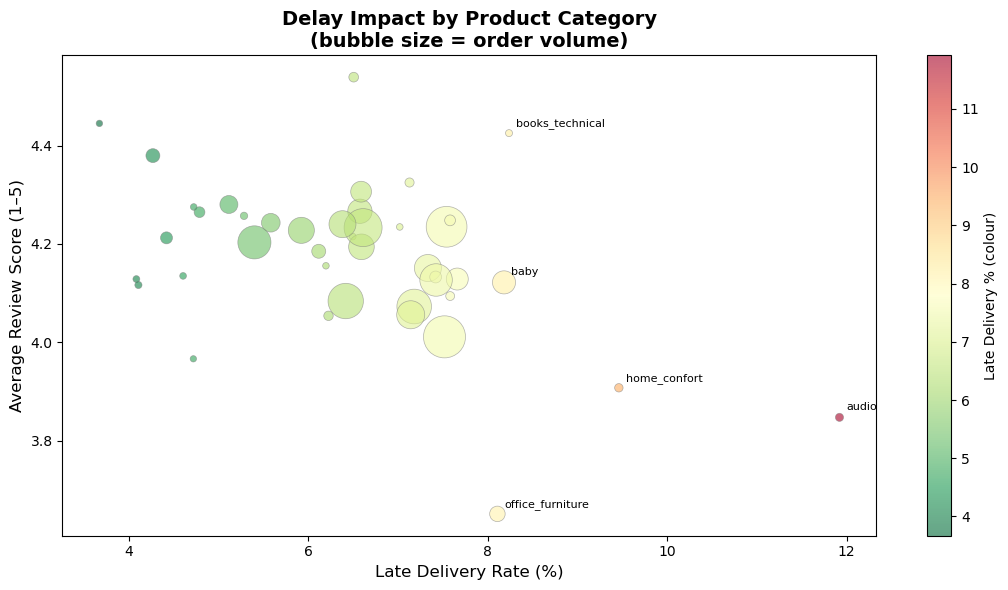

In [30]:
# Bubble chart: Late Delivery % vs Avg Review Score per product category
# Bubble size = number of orders in that category (volume context)

if "product_category_name_english" in delivered.columns:
    cat_delivered = delivered.copy()
    cat_delivered["is_late"] = cat_delivered["delay_days"] > 0

    category_stats = cat_delivered.groupby("product_category_name_english").agg(
        orders    = ("order_id",     "count"),
        pct_late  = ("is_late",      "mean"),
        avg_review= ("review_score", "mean")
    ).reset_index()

    # Remove low-volume categories (< 200 orders) to avoid noise
    category_stats = category_stats[category_stats["orders"] > 200]
    category_stats["pct_late_pct"] = category_stats["pct_late"] * 100

    fig, ax = plt.subplots(figsize=(11, 6))
    scatter = ax.scatter(
        category_stats["pct_late_pct"],
        category_stats["avg_review"],
        s=category_stats["orders"] / 10,
        alpha=0.6,
        c=category_stats["pct_late_pct"],
        cmap="RdYlGn_r",
        edgecolors="grey",
        linewidths=0.5
    )
    plt.colorbar(scatter, ax=ax, label="Late Delivery % (colour)")
    ax.set_xlabel("Late Delivery Rate (%)", fontsize=12)
    ax.set_ylabel("Average Review Score (1–5)", fontsize=12)
    ax.set_title(
        "Delay Impact by Product Category\n(bubble size = order volume)",
        fontsize=14, fontweight="bold"
    )

    # Label the top-5 worst categories (highest late %)
    worst = category_stats.nlargest(5, "pct_late_pct")
    for _, row in worst.iterrows():
        ax.annotate(
            row["product_category_name_english"],
            xy=(row["pct_late_pct"], row["avg_review"]),
            xytext=(5, 5), textcoords="offset points", fontsize=8
        )
    plt.tight_layout()
    plt.show()
else:
    # Fallback: run without English labels if order_items file was missing
    print("English category column not available. Re-run Story 5 cells after placing olist_order_items_dataset.csv in the directory.")

In [31]:
# Summary table: worst 10 categories by late delivery rate
if "product_category_name_english" in delivered.columns:
    category_stats_display = category_stats[["product_category_name_english", "orders", "pct_late_pct", "avg_review"]].copy()
    category_stats_display.columns = ["Category (English)", "Total Orders", "Late Rate (%)", "Avg Review"]
    category_stats_display["Late Rate (%)"] = category_stats_display["Late Rate (%)"].round(2)
    category_stats_display["Avg Review"]    = category_stats_display["Avg Review"].round(2)
    category_stats_display.sort_values("Late Rate (%)", ascending=False).head(10)

---
## Export Master Dataset <a id='export'></a>

Save the enriched master dataset to CSV for downstream dashboards or further analysis.

In [32]:
master.to_csv("master_cleaned.csv", index=False)
print(f"Exported master_cleaned.csv — {master.shape[0]:,} rows × {master.shape[1]} columns.")

Exported master_cleaned.csv — 99,441 rows × 20 columns.
